# graphdiff — a walkthrough

Compare two property graphs, find out **where the significant changes are**, and see it.

Everything in this notebook runs offline: no downloads, no network, no external assets. The example data is generated in-process.

In [1]:
import graphdiff as gd
from graphdiff.data import example_pair, large_example_pair, perturb_labels, example_sequence

gd.__version__

'0.1.0'

## 1. Two graphs, one report

`compare()` accepts `PropertyGraph` objects or file paths (GraphML, node-link JSON, edge-list CSV/TSV, Parquet). The result is a `ComparisonReport`; in a notebook it renders itself.

In [2]:
a, b = large_example_pair()          # ~3,000 nodes, ~10,000 edges; change concentrated in 3 of 28 communities
report = gd.compare(a, b)
report

Status,Nodes,Edges
SHARED,"3,014","8,945"
CHANGED,0,129
A_ONLY,66,743
B_ONLY,54,541
Metric,Raw,Shared
jaccard_nodes,0.9617,1.0000
overlap_nodes,0.9824,1.0000
dice_nodes,0.9805,1.0000
jaccard_edges,0.8769,0.9312
overlap_edges,0.9445,0.9657


### Findings first

The findings are the report in plain language, most important first. Each carries its evidence and points at the view where it can be seen.

In [3]:
for f in report.findings:
    print(f"[{f.severity:6}] {f.text}")

[medium] 94% similar by edit distance. 120 of 3,134 nodes and 1,413 of 10,358 edges differ — 54 nodes and 541 edges only in rebuilt, 66 nodes and 743 edges only in baseline, 129 edges reweighted.
[high  ] The change is concentrated: 3 of 28 clusters account for 94% of everything that differs. The rest of the graph is close to unchanged.
[high  ] Cluster around c16-n014 (128 nodes) had 72% of its own structure change: 22 nodes left, 18 arrived, 200 internal edges removed and 181 added.
[high  ] Cluster around c19-n068 (128 nodes) had 72% of its own structure change: 22 nodes left, 18 arrived, 195 internal edges removed and 178 added.
[high  ] Cluster around c24-n108 (128 nodes) had 72% of its own structure change: 22 nodes left, 18 arrived, 202 internal edges removed and 182 added.
[high  ] 61 well-connected nodes (degree ≥ 5) disappeared from baseline — most connected: c16-n052 (11), c19-n019 (10), c19-n009 (10).
[high  ] c24-n004 lost 4, gained 7, 1 reweighted connections (had 5, now 

### Which changes matter — significance, not proportion

Neighbourhood Jaccard is a proportion: a two-neighbour node that lost one edge scores 0.5, a 130-edge hub that lost thirty scores 0.77, and the proportion ranks them backwards. `significance` ranks by **statistical surprise** against the graph-wide background rate (leave-one-out), times a magnitude term.

In [4]:
report.top_changed(10)[["label", "status", "significance", "surprise", "n_removed", "n_added", "n_changed", "degree_a", "degree_b"]]

,label,status,significance,surprise,n_removed,n_added,n_changed,degree_a,degree_b
0,c24-n004,SHARED,54.707825,13.569764,4,7,1,5,8
1,c19-n043,SHARED,54.128889,13.415582,5,6,1,6,7
2,c24-n073,SHARED,53.855782,12.784820,5,8,0,7,10
3,c24-n027,SHARED,52.718188,12.846408,5,6,2,8,9
4,c16-n032,SHARED,52.598561,13.008026,4,6,3,8,10
5,c16-n012,SHARED,51.954047,13.039966,5,5,2,7,7
6,c19-n087,SHARED,51.422899,12.506200,7,5,0,8,6
7,c16-n052,A_ONLY,49.563741,12.394014,11,0,0,11,0
8,c19-n050,SHARED,48.625921,12.140579,3,7,2,6,10
9,c16-n072,SHARED,46.502265,11.566686,5,6,0,6,7


### Where — clusters with change density

The union is partitioned (Leiden), and each cluster's **change density** is the share of its own nodes and internal edges that differ. Three dark clusters among many pale ones is the shape real drift usually has.

In [5]:
import pandas as pd

pd.DataFrame(
    [(c.name, c.size, round(c.change_density, 3), c.n_changed_nodes, c.n_changed_edges) for c in report.clusters.clusters],
    columns=["cluster", "size", "change_density", "changed_nodes", "changed_edges"],
).sort_values("change_density", ascending=False).head(8)

,cluster,size,change_density,changed_nodes,changed_edges
0,c16-n014,128,0.725,40,421
1,c19-n068,128,0.723,40,417
2,c24-n108,128,0.720,40,420
3,c05-n044,110,0.014,0,6
4,c01-n020,110,0.014,0,6
5,c12-n044,110,0.014,0,6
6,c11-n034,110,0.011,0,5
7,c18-n063,110,0.011,0,5


### Scores, raw and on the shared subgraph

Every metric is reported over the full union (**raw**) and over the subgraph induced on nodes present in **both** graphs (**shared**), which separates "these differ in size" from "the overlapping part differs in structure". The last four rows are **label-free**: degree-distribution, spectral, NetSimile and Weisfeiler–Lehman similarities compare the *shape* of the graphs and never look at a label.

In [6]:
report.to_frame().set_index("metric")[["raw_score", "shared_subgraph_score"]].round(4)

,raw_score,shared_subgraph_score
metric,,
jaccard_nodes,0.9617,1.0000
overlap_nodes,0.9824,1.0000
dice_nodes,0.9805,1.0000
jaccard_edges,0.8769,0.9312
overlap_edges,0.9445,0.9657
dice_edges,0.9344,0.9643
jaccard_typed_edges,0.8760,0.9304
overlap_typed_edges,0.9437,0.9653
dice_typed_edges,0.9339,0.9639


## 2. The visual diff

One self-contained HTML file. It opens on the **Map** with the findings beside it — significant nodes sized and haloed, status as colour *and* shape — and has Regions, Top changes, Before/After and 3D views. `graphdiff serve diff.html` puts it on localhost for a colleague.

In [7]:
from graphdiff.viewer import write_html
from IPython.display import IFrame

path = write_html(report, "demo-diff.html")
IFrame(src=str(path), width="100%", height=620)

### Static figures

With the `[plot]` extra, the same encoding renders to PNG / SVG / PDF for slides and papers.

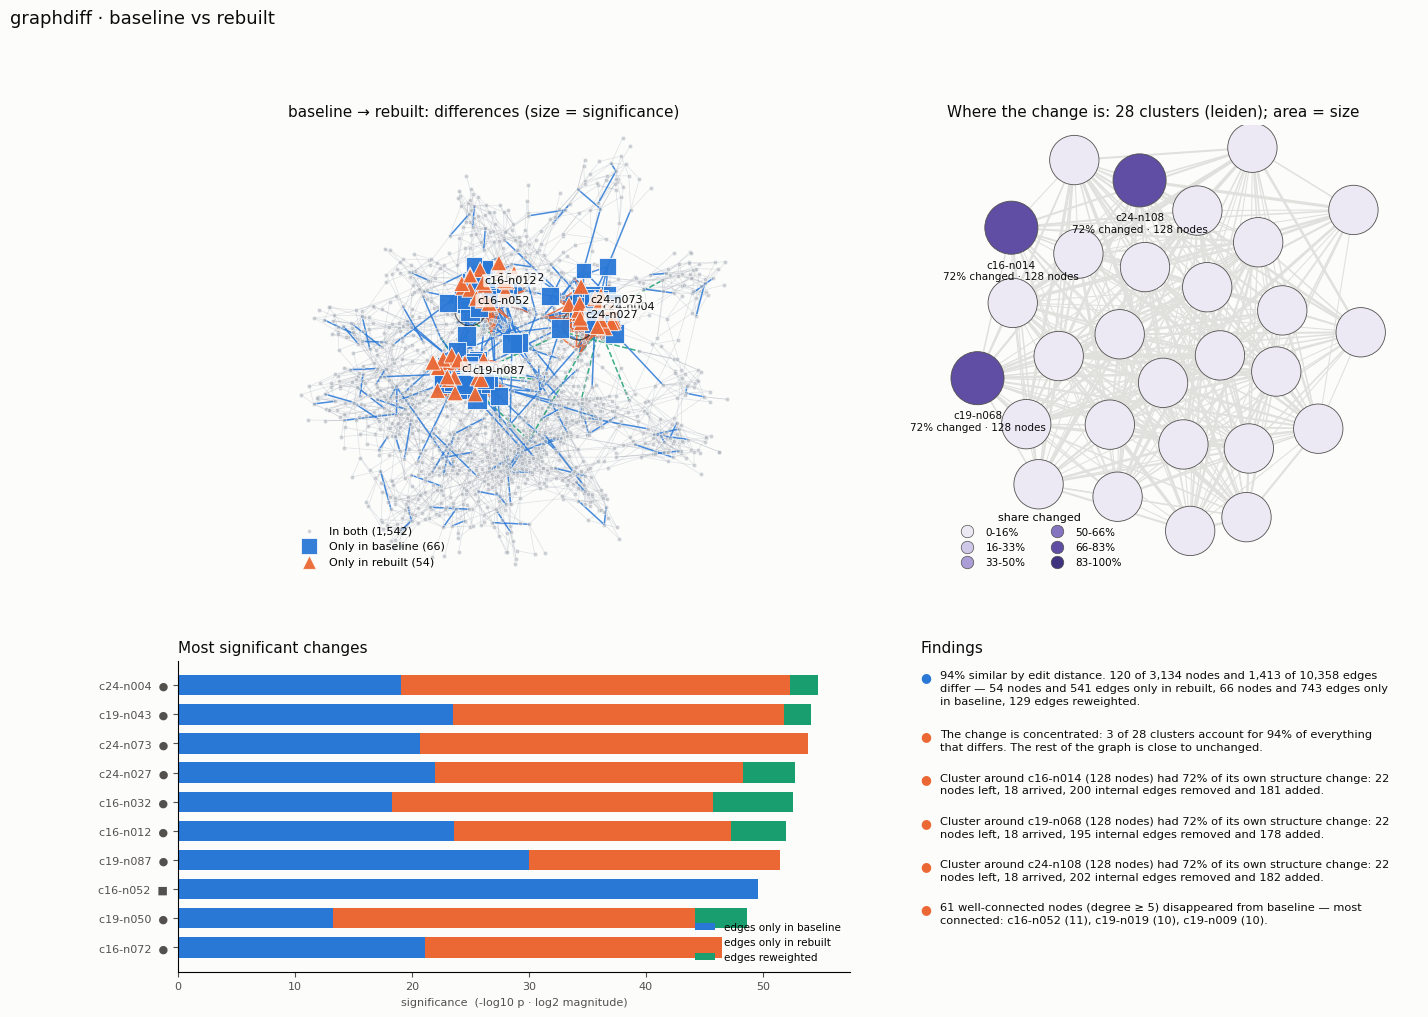

In [8]:
from graphdiff import plot

plot.plot_dashboard(report, top=10);

## 3. When labels drift — fuzzy alignment

Rename a tenth of B's labels (upper-casing, a suffix, a swapped separator, a typo). With the exact join every rename reads as a removal plus an addition; with `align="fuzzy"` the nodes are matched by label similarity **and** shared neighbourhood, each with a confidence.

In [9]:
b_renamed, truth = perturb_labels(b, fraction=0.1, seed=2, name="rebuilt-renamed")

exact = gd.compare(a, b_renamed)
fuzzy = gd.compare(a, b_renamed, align="fuzzy")
print("exact join:   similarity", round(exact.score("ged_similarity"), 3), exact.node_status_counts)
print("fuzzy align:  similarity", round(fuzzy.score("ged_similarity"), 3), fuzzy.node_status_counts)
print("truth:        similarity", round(report.score("ged_similarity"), 3), report.node_status_counts)
print()
print(fuzzy.alignment.counts)
fuzzy.alignment.fuzzy.head(8)

exact join:   similarity 0.781 {'SHARED': 2712, 'CHANGED': 0, 'A_ONLY': 368, 'B_ONLY': 356}
fuzzy align:  similarity 0.938 {'SHARED': 3007, 'CHANGED': 0, 'A_ONLY': 73, 'B_ONLY': 61}
truth:        similarity 0.94 {'SHARED': 3014, 'CHANGED': 0, 'A_ONLY': 66, 'B_ONLY': 54}

{'exact': 2712, 'normalized': 148, 'fuzzy': 147, 'unmatched_a': 73, 'unmatched_b': 61}


,label_a,label_b,method,label_similarity,structural_similarity,score,confidence,runner_up
0,c24-n091,c24-n091 Inc.,fuzzy,0.846154,0.250000,0.607692,0.432692,0.350000
1,c16-n009,c16-n009 Inc.,fuzzy,0.846154,0.400000,0.667692,0.472692,0.390000
2,c20-n060,c20xn060,fuzzy,0.583333,0.833333,0.683333,0.481282,0.404103
3,c16-n070,c16-n070 Inc.,fuzzy,0.846154,0.375000,0.657692,0.481442,0.352500
4,c11-n102,c11xn102,fuzzy,0.583333,0.833333,0.683333,0.496667,0.373333
5,c18-n035,x18-n035,fuzzy,0.583333,0.833333,0.683333,0.510417,0.345833
6,c06-n106,c06-x106,fuzzy,0.539773,1.000000,0.723864,0.515260,0.417208
7,c24-n055,c24-n055 Inc.,fuzzy,0.846154,0.500000,0.707692,0.532692,0.350000


Every inexact match was correct here — check against the ground truth:

In [10]:
inexact = fuzzy.alignment.table.query("method != 'exact'")
correct = sum(truth.get(r.label_b) == r.label_a for r in inexact.itertuples())
print(f"{correct} of {len(inexact)} inexact matches correct; least confident: {inexact.confidence.min():.2f}")

295 of 295 inexact matches correct; least confident: 0.43


## 4. More than two graphs — a timeline

Six snapshots with steady background drift, one **event** (a community torn down and replaced at t2 → t3), a **hotspot** community that keeps rewiring, and a few nodes that **flicker** in and out. The timeline should be able to narrate all three.

In [11]:
from graphdiff.batch import compare_sequence
from graphdiff.viewer import write_timeline_html

tl = compare_sequence(example_sequence())
for f in tl.findings:
    print(f"[{f.severity:6}] {f.text}")
tl.churn()

[high  ] One step dominates: t2 → t3 carries 56% of all change across the series (similarity 0.89). The other 4 steps are comparatively quiet.
[high  ] 73 nodes changed notably in at least 3 of 5 steps — a hotspot rather than a one-off: c01-n005 (5 of 5), c01-n030 (5 of 5), c01-n035 (5 of 5).
[medium] 5 nodes left and came back (or arrived and left) within the series — worth checking for an unstable source rather than a real change: c02-n008 ●·●·●·, c02-n046 ●·●·●·, c02-n022 ●·●·●·.


,step,from,to,nodes_removed,nodes_added,edges_removed,edges_added,edges_reweighted,similarity
0,0,t0,t1,4,0,82,57,1,0.976474
1,1,t1,t2,0,4,57,69,0,0.978716
2,2,t2,t3,64,60,286,252,1,0.891061
3,3,t3,t4,1,4,56,68,0,0.978723
4,4,t4,t5,4,1,68,54,0,0.979046


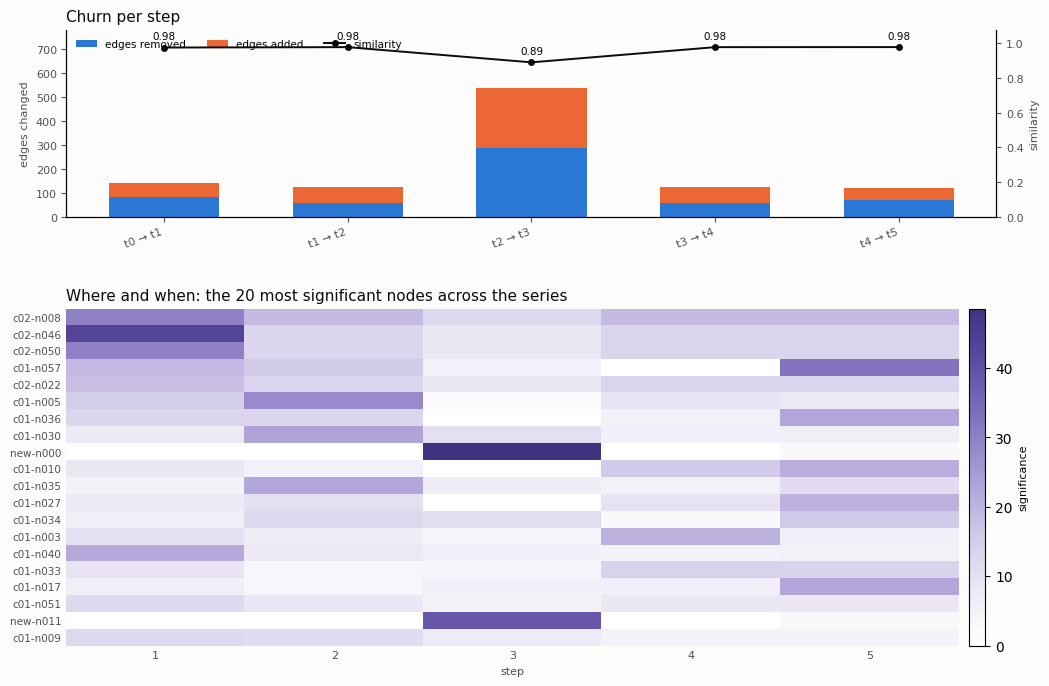

In [12]:
plot.plot_timeline(tl, max_nodes=20);

In [13]:
IFrame(src=str(write_timeline_html(tl, "demo-timeline.html", max_nodes=400)), width="100%", height=620)

## 5. In a pipeline — the regression gate

`graphdiff check` (or `run_checks` from Python) turns a comparison into a pass/fail verdict: rules on any metric, status count or significance, and drift against a stored baseline report.

In [14]:
from graphdiff.report.check import run_checks

verdict = run_checks(report, ["ged_similarity>=0.9", "nodes.A_ONLY<=50", "significance.max<=100"])
print(verdict.summary())

PASS  ged_similarity >= 0.9   (actual 0.94007)
FAIL  nodes.A_ONLY <= 50   (actual 66)
PASS  significance.max <= 100   (actual 54.7078)
1 check(s) failed


## 6. Provenance

Every report records what produced it: input hashes (for file inputs), every parameter, and library versions.

In [15]:
report.provenance["parameters"], report.provenance["environment"]

({'weight_attribute': 'weight',
  'direction': 'both',
  'cluster_by': None,
  'align': 'exact',
  'structural': True,
  'align_threshold': None,
  'ged_costs': 'unit',
  'attribute_comparison': 'all'},
 {'graphdiff': '0.1.0',
  'python': '3.11.15',
  'numpy': '2.4.4',
  'pandas': '3.0.2',
  'platform': 'Linux x86_64',
  'argv': '/usr/local/lib/python3.11/dist-packages/ipykernel_launcher.py'})